In [ ]:
import keras
from keras import models
from keras import layers
from keras import callbacks
from keras import preprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import os
from collections import Counter
from tqdm import tqdm
import tensorflow as tf

In [ ]:
# Constants
EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 100

In [ ]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        if embed_dim % num_heads != 0:
            raise ValueError(
                f"embedding dimension = {embed_dim} should be divisible by number of heads = {num_heads}"
            )
        self.projection_dim = embed_dim // num_heads
        self.query_dense = None
        self.key_dense = None
        self.value_dense = None
        self.combine_heads = None

    def build(self, input_shape):
        self.query_dense = layers.Dense(self.embed_dim)
        self.key_dense = layers.Dense(self.embed_dim)
        self.value_dense = layers.Dense(self.embed_dim)
        self.combine_heads = layers.Dense(self.embed_dim)
        super().build(input_shape)

    def attention(self, query, key, value):
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output

    def separate_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)

        attention = self.attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        output = self.combine_heads(concat_attention)
        return output

In [ ]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.att = None
        self.ffn = None
        self.layernorm1 = None
        self.layernorm2 = None
        self.dropout1 = None
        self.dropout2 = None

    def build(self, input_shape):
        self.att = MultiHeadSelfAttention(self.embed_dim, self.num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(self.ff_dim, activation="relu"),
            layers.Dense(self.embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(self.rate)
        self.dropout2 = layers.Dropout(self.rate)
        super().build(input_shape)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [ ]:
def create_transformer_emotion_model(img_size=96, num_classes=7):
    inputs = layers.Input(shape=(img_size, img_size, 1))
    
    # Initial CNN layers
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    # CNN Feature extraction
    for filters in [128, 256, 512]:
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
    
    # Get shape information
    h = x.shape[1]
    w = x.shape[2]
    c = x.shape[3]
    sequence_length = h * w
    
    # Reshape operation
    x = layers.Reshape((sequence_length, c))(x)
    
    # Create positional encoding matrix
    def get_pos_encoding(sequence_length, d_model):
        positions = tf.range(sequence_length, dtype=tf.float32)[:, tf.newaxis]
        div_term = tf.exp(tf.range(0, d_model, 2, dtype=tf.float32) * -(tf.math.log(10000.0) / d_model))
        pos_encoding = tf.zeros((sequence_length, d_model))
        
        # Calculate positional encodings
        pos_encoding = tf.tensor_scatter_nd_update(
            pos_encoding,
            tf.stack([
                tf.repeat(tf.range(sequence_length), tf.shape(div_term)[0]),
                tf.tile(tf.range(0, d_model, 2), [sequence_length])
            ], axis=1),
            tf.reshape(tf.sin(positions * div_term), [-1])
        )
        
        pos_encoding = tf.tensor_scatter_nd_update(
            pos_encoding,
            tf.stack([
                tf.repeat(tf.range(sequence_length), tf.shape(div_term)[0]),
                tf.tile(tf.range(1, d_model, 2), [sequence_length])
            ], axis=1),
            tf.reshape(tf.cos(positions * div_term), [-1])
        )
        
        return pos_encoding[tf.newaxis, ...]
    
    # Add positional encodings
    pos_encoding = layers.Lambda(
        lambda x: x + get_pos_encoding(sequence_length, c)
    )(x)
    
    # Transformer blocks
    for _ in range(4):
        pos_encoding = TransformerBlock(embed_dim=c, num_heads=8, ff_dim=2048, rate=0.1)(pos_encoding)
    
    # Final layers
    x = layers.GlobalAveragePooling1D()(pos_encoding)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

In [ ]:
# Dataset handling
def balance_dataset(data_dir, target_size=8000):
    """Balance dataset through augmentation"""
    balanced_data = []
    class_counts = Counter()

    for emotion in EMOTIONS:
        path = os.path.join(data_dir, emotion)
        class_counts[emotion] = len(os.listdir(path))

    print("Original class distribution:", class_counts)

    aug_gen = preprocessing.image.ImageDataGenerator(
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        brightness_range=[0.7, 1.3],
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    for emotion in tqdm(EMOTIONS, desc="Balancing dataset"):
        emotion_dir = os.path.join(data_dir, emotion)
        images = os.listdir(emotion_dir)
        n_augment = target_size - len(images)

        if n_augment > 0:
            print(f"Generating {n_augment} augmented images for {emotion}")
            for i in range(n_augment):
                img_path = os.path.join(emotion_dir, np.random.choice(images))
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img.reshape((1,) + img.shape + (1,))
                aug_img = next(aug_gen.flow(img, batch_size=1))[0]
                output_path = os.path.join(emotion_dir, f'aug_{i}.jpg')
                cv2.imwrite(output_path, aug_img.reshape(IMG_SIZE, IMG_SIZE))

In [ ]:
def preprocess_image(img):
    """Preprocess single image"""
    # CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img.astype(np.uint8))
    
    # Gaussian blur for noise reduction
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    # Normalize
    img = img.astype('float32') / 255.0
    return img

In [ ]:
class EmotionDataGenerator(keras.utils.Sequence):
    def __init__(self, directory, batch_size, target_size, subset='training'):
        self.directory = directory
        self.batch_size = batch_size
        self.target_size = target_size
        self.subset = subset

        self.samples = []
        for i, emotion in enumerate(EMOTIONS):
            path = os.path.join(directory, emotion)
            files = os.listdir(path)
            self.samples.extend([(os.path.join(path, f), i) for f in files])

        np.random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples) // self.batch_size

    def __getitem__(self, idx):
        batch_samples = self.samples[idx * self.batch_size:(idx + 1) * self.batch_size]
        X = np.zeros((self.batch_size, IMG_SIZE, IMG_SIZE, 1))
        y = np.zeros((self.batch_size, len(EMOTIONS)))

        for i, (path, label) in enumerate(batch_samples):
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = preprocess_image(img)
            X[i] = img.reshape(IMG_SIZE, IMG_SIZE, 1)
            y[i][label] = 1

        return X, y

In [ ]:
def plot_training_history(history):
    """Visualize training metrics"""
    metrics = ['accuracy', 'loss', 'precision', 'recall', 'auc']
    plt.figure(figsize=(15, 12))

    for i, metric in enumerate(metrics, 1):
        plt.subplot(3, 2, i)
        plt.plot(history.history[metric], label=f'Training {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        plt.title(f'Model {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, val_gen):
    """Generate and plot confusion matrix"""
    y_pred = []
    y_true = []

    for i in range(len(val_gen)):
        X_batch, y_batch = val_gen[i]
        y_pred_batch = model.predict(X_batch)
        y_pred.extend(np.argmax(y_pred_batch, axis=1))
        y_true.extend(np.argmax(y_batch, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=EMOTIONS))

def train_emotion_recognition():
    # Create data generators
    train_gen = EmotionDataGenerator('fer2013/train', BATCH_SIZE, IMG_SIZE, 'training')
    val_gen = EmotionDataGenerator('fer2013/test', BATCH_SIZE, IMG_SIZE, 'validation')

    # Create and compile model
    model = create_transformer_emotion_model()
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=1e-4,
            weight_decay=1e-5
        ),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )

    # Callbacks
    callback = [
        callbacks.ModelCheckpoint('best_model.keras', 
                       monitor='val_accuracy',
                       save_best_only=True),
        callbacks.EarlyStopping(monitor='val_loss',
                     patience=15,
                     restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss',
                         factor=0.2,
                         patience=5,
                         min_lr=1e-6)
    ]

    # Train model
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callback,
    )

    return model, history


def test_single_image(model, image_path):
    """Test model on a single image"""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_image(img)
    img = np.expand_dims(img, axis=[0, -1])

    prediction = model.predict(img)
    emotion_idx = np.argmax(prediction[0])
    confidence = prediction[0][emotion_idx]

    plt.figure(figsize=(6, 4))
    plt.imshow(img[0, :, :, 0], cmap='gray')
    plt.title(f'Predicted: {EMOTIONS[emotion_idx]}\nConfidence: {confidence:.2%}')
    plt.axis('off')
    plt.show()

    print("\nConfidence Scores:")
    for emotion, score in zip(EMOTIONS, prediction[0]):
        print(f"{emotion}: {score:.2%}")

In [ ]:
import os

# Create .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json and set permissions
os.system('mv kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')

# Download FER2013 dataset
os.system('kaggle datasets download -d msambare/fer2013')

# Create directory and extract
os.system('mkdir fer2013')
os.system('unzip fer2013.zip -d fer2013')

In [ ]:
model, history = train_emotion_recognition()

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1162/1162 ━━━━━━━━━━━━━━━━━━━━ 127s 89ms/step - accuracy: 0.1687 - loss: 2.1779 - precision: 0.1714 - recall: 0.0210 - val_accuracy: 0.1407 - val_loss: 1.9732 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - accuracy: 0.2203 - loss: 1.9073 - precision: 0.3907 - recall: 0.0144 - val_accuracy: 0.2338 - val_loss: 1.8520 - val_precision: 0.5333 - val_recall: 0.0979 - learning_rate: 0.0010
Epoch 3/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - accuracy: 0.3356 - loss: 1.7058 - precision: 0.5932 - recall: 0.0839 - val_accuracy: 0.3798 - val_loss: 1.6311 - val_precision: 0.6561 - val_recall: 0.1754 - learning_rate: 0.0010
Epoch 4/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - accuracy: 0.4488 - loss: 1.4441 - precision: 0.7028 - recall: 0.2423 - val_accuracy: 0.4642 - val_loss: 1.4316 - val_precision: 0.7696 - val_recall: 0.2070 - learning_rate: 0.0010
Epoch 5/100
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 1

## Performance Visualization Functions

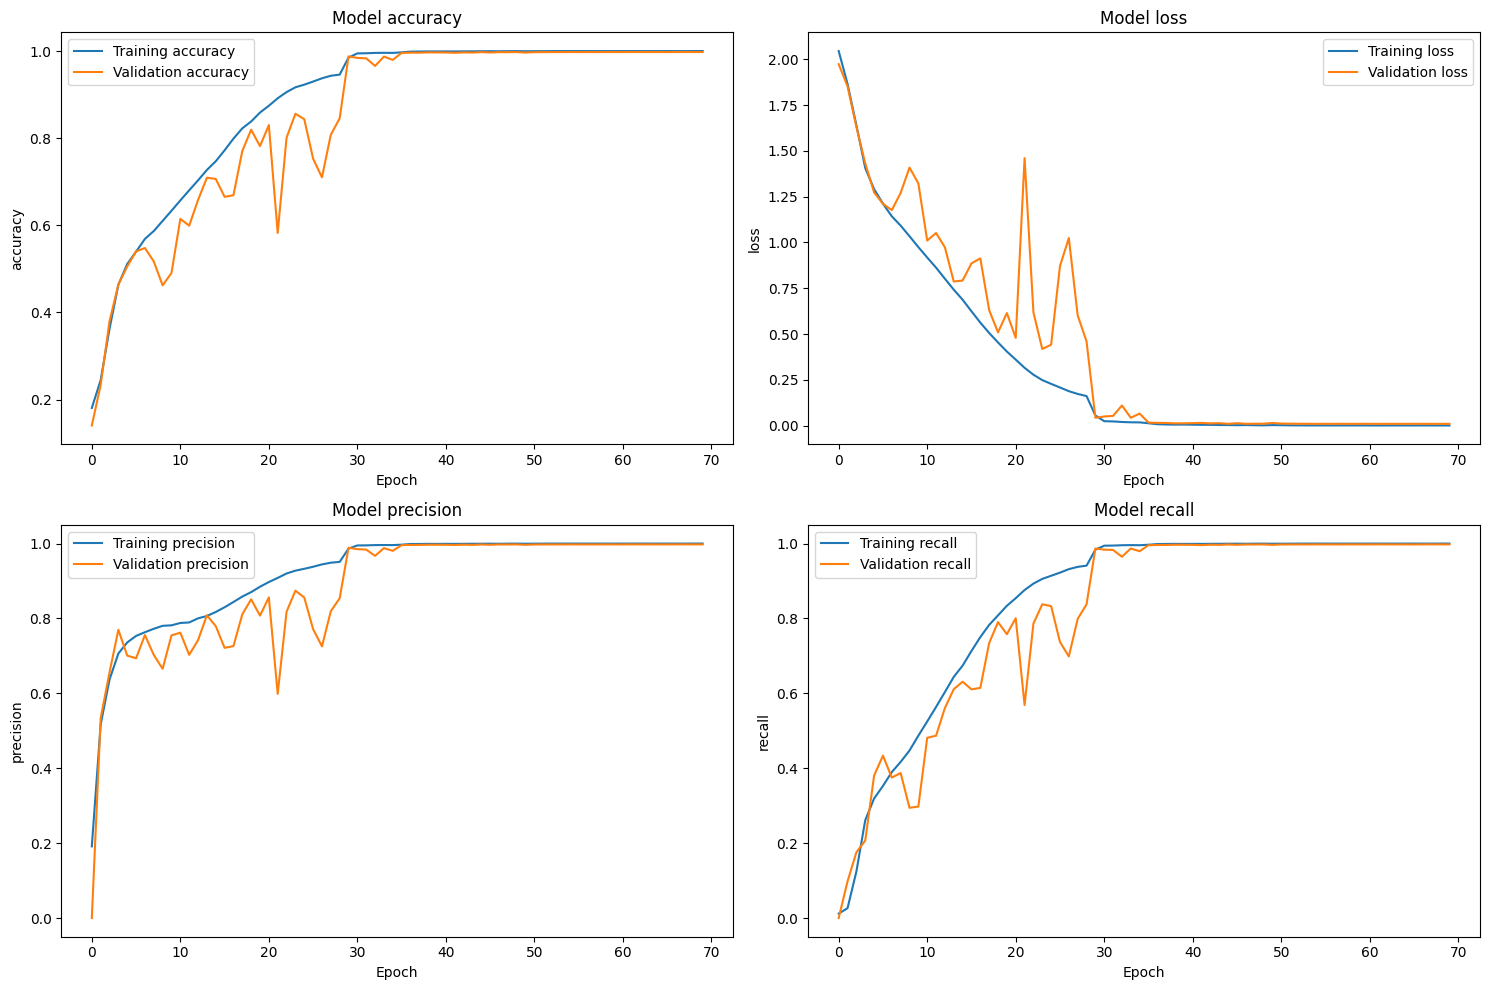

In [ ]:
def plot_training_history(history):
    """Plot training history metrics"""
    metrics = ['accuracy', 'loss', 'precision', 'recall']
    plt.figure(figsize=(15, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.plot(history.history[metric], label=f'Training {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
        plt.title(f'Model {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)


## Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

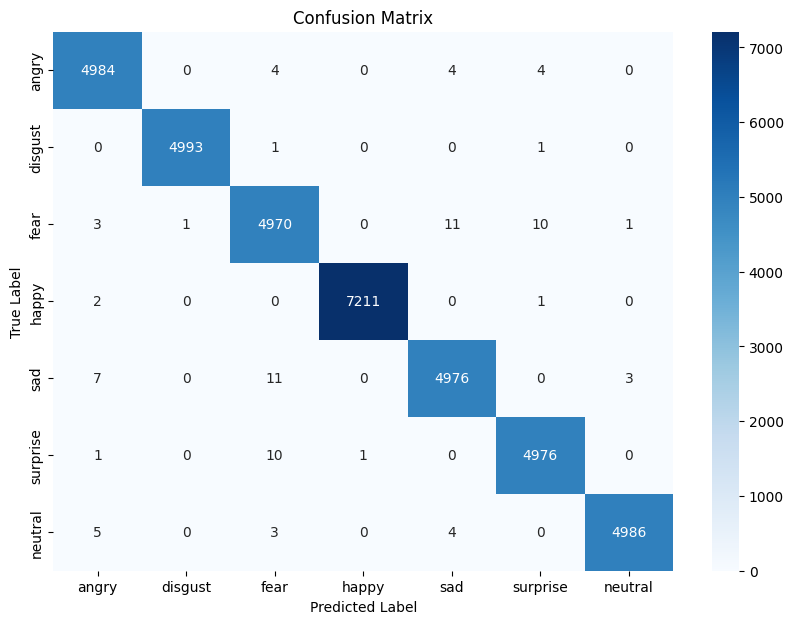

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = []
y_true = []

for i in range(len(val_gen)):
    X_batch, y_batch = val_gen[i]
    y_pred_batch = model.predict(X_batch)
    y_pred.extend(np.argmax(y_pred_batch, axis=1))
    y_true.extend(np.argmax(y_batch, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()


## Save Model and Training History

In [ ]:
final_metrics = model.evaluate(val_gen)
print("\nFinal Model Performance:")
print(f"Loss: {final_metrics[0]:.4f}")
print(f"Accuracy: {final_metrics[1]:.4f}")
print(f"Precision: {final_metrics[2]:.4f}")
print(f"Recall: {final_metrics[3]:.4f}")

1162/1162 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.9977 - loss: 0.0090 - precision: 0.9977 - recall: 0.9977

Final Model Performance:
Loss: 0.0096
Accuracy: 0.9976
Precision: 0.9976
Recall: 0.9976
